In [ ]:
import sys
import numpy as np

print("Python version:", sys.executable)
print("NumPy version:", np.__version__)

Python version: /opt/homebrew/anaconda3/envs/ai-from-scratch/bin/python
NumPy version: 2.4.6


In [2]:
v = np.array([1, 2])

A = np.array([[2, 0], [0, 2]])
B = np.array([[0,-1], [1, 0]])

print("original: ", v)
print("A * v =", A @ v)
print("B * v =", B @ v)

original:  [1 2]
A * v = [2 4]
B * v = [-2  1]


Matplotlib is building the font cache; this may take a moment.


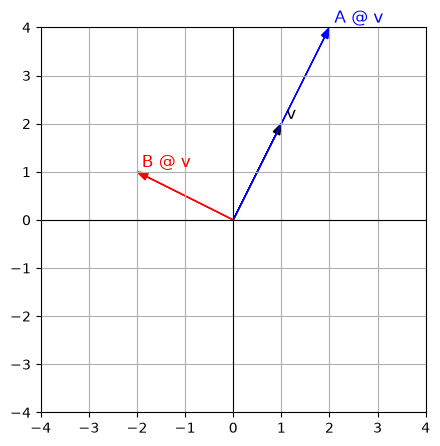

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_vectors(vectors, labels, colors):
    plt.figure(figsize=(5, 5))
    ax = plt.gca()

    for v, label, color in zip(vectors, labels, colors):
        ax.arrow(
            0, 0, v[0], v[1],
            head_width=0.15,
            length_includes_head=True,
            color=color
        )
        ax.text(v[0] + 0.1, v[1] + 0.1, label, color=color, fontsize=12)

    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.grid(True)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    plt.show()

v = np.array([1, 2])

A = np.array([
    [2, 0],
    [0, 2],
])

B = np.array([
    [0, -1],
    [1, 0],
])

plot_vectors(
    [v, A @ v, B @ v],
    ["v", "A @ v", "B @ v"],
    ["black", "blue", "red"]
)

- v = [1,2]
- A @ v = [2,4] : 같은 방향으로 2배 2E
- B @ v = [-2,1] : 반시계 방향으로 90도 회전

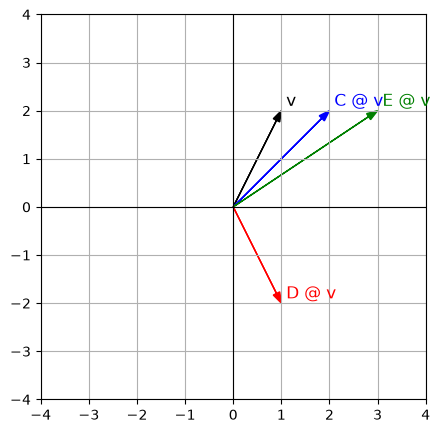

In [ ]:
C = np.array([
    [2, 0],
    [0, 1],
])
# x축으로 2배, y축으로 1배 늘어나는 변환

D = np.array([
    [1, 0],
    [0, -1],
])

# x축은 그대로, y축은 반전되는 변환

E = np.array([
    [1, 1],
    [0, 1],
])

# x좌표가 y값에 비례해서 옆으로 밀어내는 변환, y축은 그대로

plot_vectors(
    [v, C @ v, D @ v, E @ v],
    ["v", "C @ v", "D @ v", "E @ v"],
    ["black", "blue", "red", "green"]
)

행렬 = 변환

# 행렬 곱 순서
같은 A B 라도 결과가 달라질 수 있다

In [8]:
v = np.array([1, 2])

scale = np.array([
    [2, 0],
    [0, 2],
])

shear = np.array([
    [1, 1],
    [0, 1],
])

print("scale then shear:", shear @ scale @ v)
print("shear then scale:", scale @ shear @ v)

stretch_x = np.array([
    [2, 0],
    [0, 1],
])

rotate_90 = np.array([
    [0, -1],
    [1, 0],
])

print("stretch then rotate:", rotate_90 @ stretch_x @ v)
print("rotate then stretch:", stretch_x @ rotate_90 @ v)

scale then shear: [6 4]
shear then scale: [6 4]
stretch then rotate: [-2  2]
rotate then stretch: [-4  1]


오른쪽에 있는 연산이 먼저 적용된다

# 2. dot product
dot product는 두 벡터가 얼마나 같은 방향을 보고 있는지 재는 방법이다. (내적, 스칼라곱)

In [9]:
a = np.array([1, 2])
b = np.array([2, 4])
c = np.array([-2, 1])

print(np.dot(a, b))
print(np.dot(a, c))

10
0


- 양수: 비슷한 방향
- 0: 수직
- 음수: 반대 방향 성분이 있음

이게 엄청 중요한게, 검색, 추천, RAG, attention에서 "비슷한 벡터 찾기"에 자주 씀

# 3. norm / magnitude
백터의 길이도 같이 봐야함

In [ ]:
a = np.array([3, 4])

print(np.linalg.norm(a)) # 벡터 a의 크기
# linalg : linear algebra의 약자
# norm : 벡터의 크기/길이

# 피타고라스의 정리
# sqrt(3^2 + 4^2) = 5

5.0


# 4. cosine similarity
dot product는 벡터의 길이에 영향을 받는다. 그래서 방향만 비교하고 싶다면 cosine similarity를 사용.

In [ ]:
# 코사인 유사도는 두 벡터 간의 각도를 측정하는 방법으로, -1에서 1 사이의 값을 가진다.
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)) 
    
a = np.array([1, 0])
b = np.array([2, 4])
c = np.array([-2, 1])

print(cosine_similarity(a, b))
print(cosine_similarity(a, c))

0.4472135954999579
-0.8944271909999159


- a · b = |a| * |b| * cos(theta)
- (a · b) / (|a| * |b|) = cos(theta)
- 내적 / 길이 = 방향만 남음. 이게 바로 cosine similarity

embedding vector를 비교할 때 "크기가 큰 벡터"가 무조건 이기는 걸 막고싶기 때문에 한다.